# LFC analysis.

Calculates LFC tables:

- with traditional T0 null distribution;
- with the matched sample of end timepoint, EPO vs BC.

Kexin Dong

Dec 6, 2025

Updated Jan 26, 2026: Remove outlier control guides.  
Updated Feb 27, 2026: Do the traditional analysis method for the barcoding arm of the screen.  
Updated March 30, 2026: Rerun with new CBE screen data.


# ABE Validation Library. 
- 45% targets
    - min edit = 10
    - FDR cutoff = .1
    - LFC cut off (in any tissue/ in vitro) = 1. 
- 55% controls
    - non-targeting controls (50%)
        - include all original NTs
    - safe-targeting controls (5%)

# CBE Focused Library. 
- 65% targets
    - Pax5, Trp53, Cttnb1 
    - leukemia-relavant genes 
    - truncation mutation in targeting genes
- 35% controls
    - non-targeting controls (25%)
        - include all original NTs 
    - safe-targeting controls (5%)
    - truncation mutation in essential genes (10%)

# METHOD 1: Traditional method; EPO screen only. 

Use this one to calculate the correlation of control guides.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA

## 1. normalize thre read counts of each sample to RPM (reads per million).

In [2]:
fp = 'counts/focused'
ABE_BC_COUNTS = pd.read_csv(fp + '/FC_ABE_BC_COUNTS.txt', sep='\t')
CBE_BC_COUNTS = pd.read_csv(fp + '/FC_CBE_BC_COUNTS_new.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv(fp + '/FC_ABE_EPO_COUNTS.txt', sep='\t')
CBE_EPO_COUNTS = pd.read_csv(fp + '/FC_CBE_EPO_COUNTS_new.txt', sep='\t')

In [3]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_BC_COUNTS.columns[2:])
ABE_BC_RPM = ABE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_BC_RPM[k] = rpm

In [4]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_EPO_COUNTS.columns[2:])
ABE_EPO_RPM = ABE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_EPO_RPM[k] = rpm

In [5]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_BC_COUNTS.columns[2:])
CBE_BC_RPM = CBE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_BC_RPM[k] = rpm

In [6]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_EPO_COUNTS.columns[2:])
CBE_EPO_RPM = CBE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_EPO_RPM[k] = rpm

## 2. Generate LFC tables

In [7]:
#start with ABE

def LFC_table_generator(RPM_df, samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3']):
    """ 
    Function for generating LFC values
    RPM_df = dataframe containing RPM values (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    t0_comparison = list containing base mean values for LFC calculation
    """

    dmso_median = np.median(RPM_df[t0_comparison], axis=1)

    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):

        samp_of_interest = samp_dict[condition_of_interest]

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM_df[k]
            lfc = np.log2(col/dmso_median)
            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['Input_median'] = dmso_median
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

In [130]:
ABE_EPO_samps_to_merge = ABE_BC_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'],
# ['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
ABE_EPO_new_name = ABE_BC_new_name = ['bm', 'd15', 'd5','input','lib','spleen']

CBE_EPO_samps_to_merge = CBE_BC_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5','bm6','bm7','bm8','bm9','bm10'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6', 'spleen7', 'spleen8', 'spleen9', 'spleen10']]
CBE_EPO_new_name = CBE_BC_new_name = ['bm', 'd15', 'd5','input','lib', 'spleen']

In [131]:
ABE_EPO_SAMP_DICT = ABE_BC_SAMP_DICT = dict(zip(ABE_EPO_new_name, ABE_EPO_samps_to_merge))
CBE_BC_SAMP_DICT = dict(zip(CBE_BC_new_name, CBE_BC_samps_to_merge))
CBE_EPO_SAMP_DICT = dict(zip(CBE_EPO_new_name, CBE_EPO_samps_to_merge))

In [14]:
#generate LFC tables
ABE_EPO_LFC = LFC_table_generator(ABE_EPO_RPM, ABE_EPO_SAMP_DICT, t0_comparison=['input'])
CBE_EPO_LFC = LFC_table_generator(CBE_EPO_RPM, CBE_EPO_SAMP_DICT, t0_comparison=['input'])
ABE_BC_LFC = LFC_table_generator(ABE_BC_RPM, ABE_BC_SAMP_DICT, t0_comparison=['input'])
CBE_BC_LFC = LFC_table_generator(CBE_BC_RPM, CBE_BC_SAMP_DICT, t0_comparison=['input'])

In [20]:
fp = 'MLE/focused/'
D5_ABE_BC = pd.read_csv(os.path.join(fp,'ABE_BC','d5.csv'))
D5_ABE_EPO = pd.read_csv(os.path.join(fp,'ABE_EPO','d5.csv'))
D5_CBE_BC = pd.read_csv(os.path.join(fp,'CBE_BC_NEW','d5.csv'))
D5_CBE_EPO = pd.read_csv(os.path.join(fp,'CBE_EPO_NEW','d5.csv'))

In [21]:
#and then adding in editing information to the dataframe
ABE_EPO_EDITING = D5_ABE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_EPO_EDITING = ABE_EPO_EDITING[ABE_EPO_EDITING['gRNA_id'].isin(ABE_EPO_COUNTS['sgRNA'])]

CBE_EPO_EDITING = D5_CBE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_EPO_EDITING = CBE_EPO_EDITING[CBE_EPO_EDITING['gRNA_id'].isin(CBE_EPO_COUNTS['sgRNA'])]

ABE_BC_EDITING = D5_ABE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_BC_EDITING = ABE_BC_EDITING[ABE_BC_EDITING['gRNA_id'].isin(ABE_BC_COUNTS['sgRNA'])]

CBE_BC_EDITING = D5_CBE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_BC_EDITING = CBE_BC_EDITING[CBE_BC_EDITING['gRNA_id'].isin(CBE_BC_COUNTS['sgRNA'])]

In [23]:
#also add in information about the edits of interest
library = pd.read_csv('MBESv2_focused_with_PAM.csv')[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]
library

,gRNA_id,gene_name_m_corrected,gene_name_h,HGVSp_m,HGVSp_h,classification,classification_m
0,gRNA_2,Abl1,ABL1,Non-coding,NaN,targeting guide,Intron
1,gRNA_4,Abl1,ABL1,E1060K,E1048K,targeting guide,Missense
2,gRNA_19,Abl1,ABL1,P592L,P573L,targeting guide,Missense
3,gRNA_21,Abl1,ABL1,A737T,A719T,targeting guide,Missense
4,gRNA_85,Akt1,AKT1,D323G,D323G,targeting guide,Missense
...,...,...,...,...,...,...,...
1628,gRNA_15007,NaN,NaN,NaN,NaN,non-targeting control,NaN
1629,gRNA_15008,NaN,NaN,NaN,NaN,non-targeting control,NaN
1630,gRNA_15009,NaN,NaN,NaN,NaN,non-targeting control,NaN
1631,gRNA_15010,NaN,NaN,NaN,NaN,non-targeting control,NaN


In [24]:
library['classification'].unique()

array(['targeting guide', 'non-targeting control',
       'essential truncation guide', 'safe-targeting control'],
      dtype=object)

In [25]:
ABE_EPO_EDITING = pd.merge(ABE_EPO_EDITING, library, on='gRNA_id')
ABE_BC_EDITING = pd.merge(ABE_BC_EDITING, library, on='gRNA_id')
CBE_EPO_EDITING = pd.merge(CBE_EPO_EDITING, library, on='gRNA_id')
CBE_BC_EDITING = pd.merge(CBE_BC_EDITING, library, on='gRNA_id')

In [26]:
ABE_BC_LFC_table_w_editing = pd.merge(ABE_BC_LFC, ABE_BC_EDITING, on='gRNA_id')
ABE_EPO_LFC_table_w_editing = pd.merge(ABE_EPO_LFC, ABE_EPO_EDITING, on='gRNA_id')
CBE_BC_LFC_table_w_editing = pd.merge(CBE_BC_LFC, CBE_BC_EDITING, on='gRNA_id')
CBE_EPO_LFC_table_w_editing = pd.merge(CBE_EPO_LFC, CBE_EPO_EDITING, on='gRNA_id')

In [28]:
#calculating z-scores for standardization of comparison
samples = ['bm', 'd15', 'd5', 'spleen']
def z_score(df, samples):
    for x in samples:
        col_median = f'LFC_median_{x}'
        avg = np.average(df[col_median])
        std = np.std(df[col_median])
        z_scores = (df[col_median]-avg)/std
        df[f'z_score_{x}'] = z_scores
    return df

ABE_BC_LFC_table_w_editing_z_score = ABE_BC_LFC_table_w_editing.copy()
ABE_EPO_LFC_table_w_editing_z_score = ABE_EPO_LFC_table_w_editing.copy()
CBE_BC_LFC_table_w_editing_z_score = CBE_BC_LFC_table_w_editing.copy()
CBE_EPO_LFC_table_w_editing_z_score = CBE_EPO_LFC_table_w_editing.copy()

ABE_BC_LFC_table_w_editing_z_score = z_score(ABE_BC_LFC_table_w_editing_z_score, samples)
ABE_EPO_LFC_table_w_editing_z_score = z_score(ABE_EPO_LFC_table_w_editing_z_score, samples)
CBE_BC_LFC_table_w_editing_z_score = z_score(CBE_BC_LFC_table_w_editing_z_score, samples)
CBE_EPO_LFC_table_w_editing_z_score = z_score(CBE_EPO_LFC_table_w_editing_z_score, samples)

In [29]:
yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

## 3. Construction & visualization of null distributions
- w/o bootstrapping?
- with controls in the EPO screen first

In [30]:
#set np random seed for reproducibility
np.random.seed(0)
null=['non-targeting control', 'safe-targeting control']

### 3.1 with controls in the EPO screen

(array([12., 51., 82., 45., 13.,  2.,  0.,  0.,  0.,  1.]),
 array([6.38650399e+00, 1.33852689e+03, 2.67066727e+03, 4.00280765e+03,
        5.33494803e+03, 6.66708842e+03, 7.99922880e+03, 9.33136918e+03,
        1.06635096e+04, 1.19956499e+04, 1.33277903e+04]),
 <BarContainer object of 10 artists>)

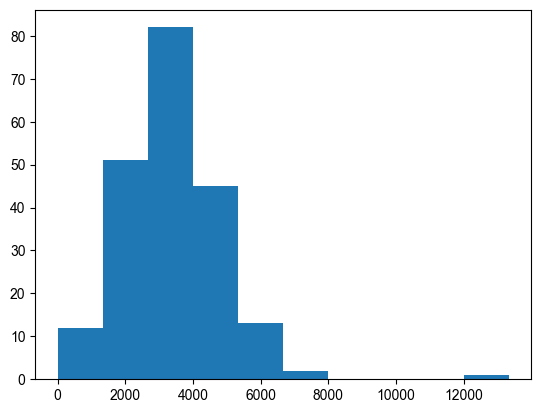

In [31]:
ABE_controls = ABE_EPO_LFC_table_w_editing[ABE_EPO_LFC_table_w_editing['classification'].isin(null)].reset_index(drop=True)
plt.hist(ABE_controls['Input_median'])

(array([234.,  82.,  81.,  66.,  46.,  31.,  16.,   5.,   2.,   3.]),
 array([1.62015945e-01, 2.69853758e+02, 5.39545500e+02, 8.09237242e+02,
        1.07892898e+03, 1.34862073e+03, 1.61831247e+03, 1.88800421e+03,
        2.15769595e+03, 2.42738769e+03, 2.69707944e+03]),
 <BarContainer object of 10 artists>)

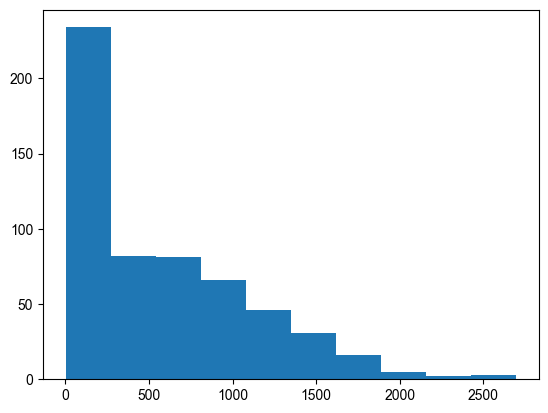

In [32]:
CBE_controls = CBE_EPO_LFC_table_w_editing[CBE_EPO_LFC_table_w_editing['classification'].isin(null)].reset_index(drop=True)
plt.hist(CBE_controls['Input_median'])

In [33]:
ABE_controls = ABE_EPO_LFC_table_w_editing[ABE_EPO_LFC_table_w_editing['classification'].isin(null)].reset_index(drop=True)
CBE_controls = CBE_EPO_LFC_table_w_editing[CBE_EPO_LFC_table_w_editing['classification'].isin(null)].reset_index(drop=True)

In [35]:
#generate null distributions with bootstrapping
conditions = ['d5', 'd15', 'spleen', 'bm']

ABE_bootstrapped_nulls = []
CBE_bootstrapped_nulls = []

for condition in conditions:
    samp_of_interest_CBE = CBE_EPO_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_EPO_SAMP_DICT[condition]

    #combine replicates and bootstrap sample
    nt_gRNA_values_CBE = CBE_controls[samp_of_interest_CBE].to_numpy().flatten()
    bootstrapped_dist_CBE = np.random.choice(nt_gRNA_values_CBE, size=10000, replace=True)

    nt_gRNA_values_ABE = ABE_controls[samp_of_interest_ABE].to_numpy().flatten()
    bootstrapped_dist_ABE = np.random.choice(nt_gRNA_values_ABE, size=10000, replace=True)

    CBE_bootstrapped_nulls.append(bootstrapped_dist_CBE)
    ABE_bootstrapped_nulls.append(bootstrapped_dist_ABE)

#create dictionaries for both
ABE_null_dict = dict(zip(conditions, ABE_bootstrapped_nulls))
CBE_null_dict = dict(zip(conditions, CBE_bootstrapped_nulls))

In [36]:
len(nt_gRNA_values_CBE)

5660

In [37]:
len(nt_gRNA_values_ABE)

1030

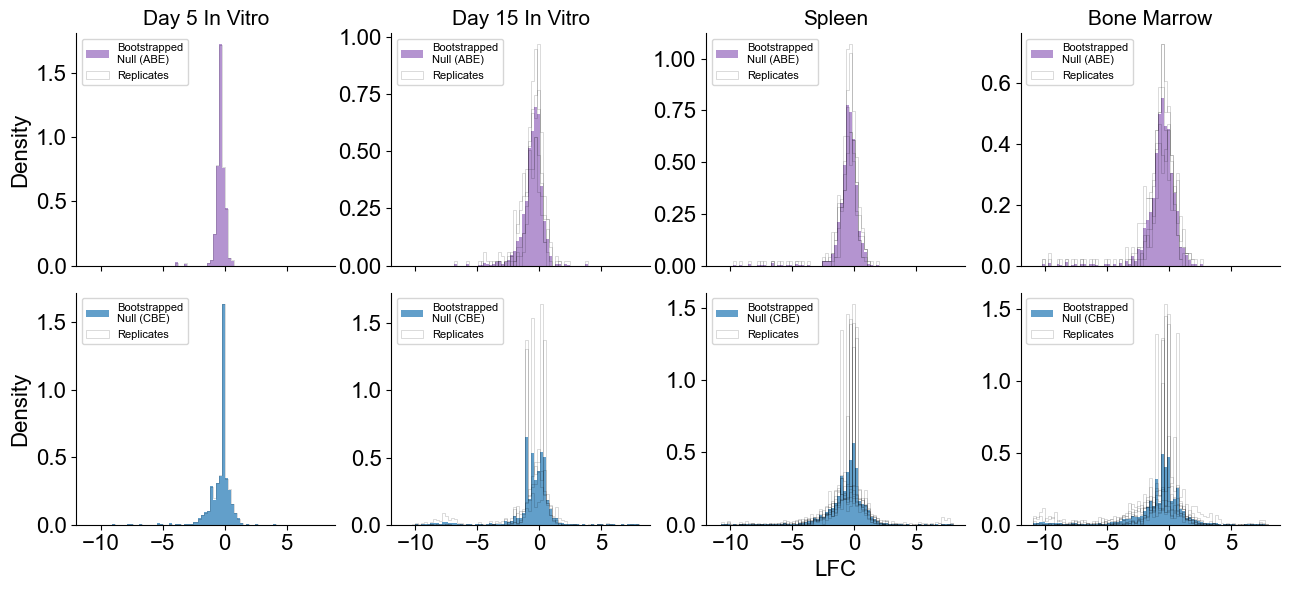

In [44]:
#visualizing the null distributions

fig, ax = plt.subplots(2,4, figsize=(13,6), sharex=True, sharey=False)

conditions = ['d5', 'd15', 'spleen', 'bm']
name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow']))

for idx, condition in enumerate(conditions):
    bins = np.linspace(-11,8,80)

    ax[0][idx].hist(ABE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:purple', label='Bootstrapped\nNull (ABE)')
    ax[1][idx].hist(CBE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:blue', label='Bootstrapped\nNull (CBE)')

    ax[0][idx].set_title(name_dict[condition], fontsize=15)

    ax[0][idx].spines[['top', 'right']].set_visible(False)
    ax[1][idx].spines[['top', 'right']].set_visible(False)

    ax[0][idx].tick_params(axis='both', which='major', labelsize=16);
    ax[1][idx].tick_params(axis='both', which='major', labelsize=16);
    
    ax[0][0].set_ylabel('Density', fontsize=16)
    ax[1][0].set_ylabel('Density', fontsize=16)
    ax[1][2].set_xlabel('LFC', fontsize=16)

    ax[0][0].set_xticks([-10,-5,0,  5])

    #also plot the replicates
    samp_of_interest_CBE = CBE_EPO_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_EPO_SAMP_DICT[condition]

    for idx2, k in enumerate(samp_of_interest_ABE):
        if idx2==0:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    for idx2, k in enumerate(samp_of_interest_CBE):
        if idx2==0:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    ax[0][idx].legend(fontsize=8, loc='upper left')
    ax[1][idx].legend(fontsize=8, loc='upper left')

fig.tight_layout()
plt.savefig('figures_new_cbe/12_1_null_epo.pdf')

## 4. Empirical p-value & FDR calculation

"Therefore, this simple experiment indicates that there can be significant benefits to using Stouffer’s method in place of Fisher’s method, particularly when long-tailed or off-target effects can be present in the null distribution and are difficult to accurately model."

In [45]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests

# Function to compute empirical p-values
def empirical_p_value(observed, null_distribution):
    S_high = sum(null_distribution >= observed)
    S_low = sum(null_distribution <= observed)
    N = len(null_distribution)

    # Compute two-sided p-value
    p_high = (S_high + 1) / (N + 1)
    p_low = (S_low + 1) / (N + 1)
    return p_high, p_low

def two_sided_FDR(condition_of_interest, samp_of_interest, LFC_df, null_dict):
    ''' 
    condition_of_interest = name of condition (e.g. "spleen")
    samp_of_interest = list of all replicates ["spleen1", "spleen2", "spleen3"]
    LFC_df = dataframe with LFC values
    null_dict = dictionary containing bootstrapped null distributions for each tissue & editor combination
    '''

    # Load the null distribution
    nt_gRNA_values = null_dict[condition_of_interest]

    # Targeting gRNAs (including NT for completeness)
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])
    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    combined_p_values_high_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_high
    ])
    combined_p_values_low_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    adjusted_p_values_high_stouffers = multipletests(combined_p_values_high_stouffers, method='fdr_bh')[1]
    adjusted_p_values_low_stouffers = multipletests(combined_p_values_low_stouffers, method='fdr_bh')[1]

    # Store results in the dataframe
    LFC_df[f'p_high_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_high
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_low
    LFC_df[f'FDR_high_{condition_of_interest}_fishers'] = adjusted_p_values_high
    LFC_df[f'FDR_low_{condition_of_interest}_fishers'] = adjusted_p_values_low

    LFC_df[f'p_high_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_high_stouffers
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_low_stouffers
    LFC_df[f'FDR_high_{condition_of_interest}_stouffers'] = adjusted_p_values_high_stouffers
    LFC_df[f'FDR_low_{condition_of_interest}_stouffers'] = adjusted_p_values_low_stouffers

    #Combine low and high FDRs for ease of manipulation and plotting
    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_fishers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_fishers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_fishers'] = min_FDR

    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_stouffers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_stouffers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_stouffers'] = min_FDR

    return LFC_df

### 4.1 Traditional, W/ the null distribution of control guides in the epo screen

In [46]:
#first perform computation for ABE samples

conditions = ['d5', 'd15', 'spleen', 'bm']

df_holder_ABE = []
for condition_of_interest in conditions:

    samp_of_interest = ABE_EPO_SAMP_DICT[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, ABE_EPO_LFC_table_w_editing, ABE_null_dict)

    df_holder_ABE.append(LFC_df)

combined_LFC_FDR_ABE = pd.concat(df_holder_ABE, axis=1)
combined_LFC_FDR_ABE = combined_LFC_FDR_ABE.loc[:,~combined_LFC_FDR_ABE.columns.duplicated()].copy()

In [47]:

#then do the same for CBE samples
conditions = ['d5', 'd15', 'spleen', 'bm']

df_holder_CBE = []
for condition_of_interest in conditions:

    samp_of_interest = CBE_EPO_SAMP_DICT[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, CBE_EPO_LFC_table_w_editing, CBE_null_dict)

    df_holder_CBE.append(LFC_df)

combined_LFC_FDR_CBE = pd.concat(df_holder_CBE, axis=1)
combined_LFC_FDR_CBE = combined_LFC_FDR_CBE.loc[:,~combined_LFC_FDR_CBE.columns.duplicated()].copy()

In [48]:
#save dataframes
combined_LFC_FDR_ABE.to_csv('LFC-FDR/focused/ABE_LFC_FDR_df_focused.csv', index=False)
combined_LFC_FDR_CBE.to_csv('LFC-FDR/focused/CBE_LFC_FDR_df_focused.csv', index=False)

### 4.3 add p_stouffers to the OG screen result

In [87]:
#loading in barcode counts
fp = '/Users/kexindong/Documents/GitHub/SG-B-ALL-in-vivo-base-editing'
ABE_counts = pd.read_csv(f'{fp}/mageck/ABE_bc_counts.txt', sep='\t')
CBE_counts = pd.read_csv(f'{fp}/mageck/CBE_bc_counts.txt', sep='\t')

#and normalize to generate RPM values
samples_CBE = list(CBE_counts.columns[2:])

CBE_RPM = CBE_counts.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1
for k in samples_CBE:
    col = np.asarray(CBE_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_RPM[k] = rpm

#and do the same for ABE
ABE_RPM = ABE_counts.copy()
samples_ABE = list(ABE_counts.columns[2:])

pseudocount = 1
for k in samples_ABE:
    col = np.asarray(ABE_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_RPM[k] = rpm

ABE_RPM = ABE_counts.copy()
samples_ABE = list(ABE_counts.columns[2:])

pseudocount = 1
for k in samples_ABE:
    col = np.asarray(ABE_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_RPM[k] = rpm

ABE_RPM = ABE_counts.copy()
samples_ABE = list(ABE_counts.columns[2:])

pseudocount = 1
for k in samples_ABE:
    col = np.asarray(ABE_counts[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_RPM[k] = rpm

In [88]:
#instatiate dictionaries containing information about all of the samples and their corresponding replicates
CBE_samp_dict = {'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5','spleen6','spleen7','spleen8','spleen9'],
 'bonemarrow':['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5','bonemarrow6','bonemarrow7','bonemarrow8','bonemarrow9','bonemarrow10'],
 'meninges':['meninges1','meninges2','meninges3','meninges4','meninges5','meninges6','meninges7','meninges8','meninges9','meninges10',],
 'd5':['d5_rep1','d5_rep2','d5_rep3'],
 'd15':['d15_rep1','d15_rep2','d15_rep3'],
 'plasmid_lib':['plasmidlib']}

ABE_samp_dict = {'spleen':['spleen1','spleen2','spleen3','spleen4'],
 'bonemarrow':['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
 'meninges':['meninges1','meninges2','meninges3','meninges4','meninges5'],
 'd5':['d5_rep1','d5_rep2','d5_rep3'],
 'd15':['d15_rep1','d15_rep2','d15_rep3'],
 'plasmid_lib':['plasmidlib']}

In [89]:
#start with ABE

def LFC_table_generator(RPM_df, samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3']):
    """ 
    Function for generating LFC values
    RPM_df = dataframe containing RPM values (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    t0_comparison = list containing base mean values for LFC calculation
    """


    dmso_median = np.median(RPM_df[t0_comparison], axis=1)

    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):

        samp_of_interest = samp_dict[condition_of_interest]

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM_df[k]
            lfc = np.log2(col/dmso_median)

            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['Input_median'] = dmso_median
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

In [90]:
#generate LFC tables
ABE_LFC_table = LFC_table_generator(ABE_RPM, ABE_samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3'])
CBE_LFC_table = LFC_table_generator(CBE_RPM, CBE_samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3'])

In [91]:
#add in editing information
#USING THE D5 EDITING AS PROXY FOR ALL OTHER EDITING
d5_abe = pd.read_csv(f'{fp}/ABE_editing/MLE/d5_ABE_MLE.csv')
##---USING UPDATED CBE EDITING THAT INCLUDES LEGACY GUIDES!!---
d5_cbe = pd.read_csv(f'{fp}/CBE_editing_UPDATED/MLE/d5_CBE_MLE.csv')

#and then adding in editing information to the dataframe
abe_editing = d5_abe[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc',	'target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
abe_editing = abe_editing[abe_editing['gRNA_id'].isin(ABE_counts['sgRNA'])]

cbe_editing = d5_cbe[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc',	'target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
cbe_editing = cbe_editing[cbe_editing['gRNA_id'].isin(CBE_counts['sgRNA'])]


#also add in information about the edits of interest
library = pd.read_csv('MBESv2_CORRECTED.csv')[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]
abe_editing = pd.merge(abe_editing, library, on='gRNA_id')
cbe_editing = pd.merge(cbe_editing, library, on='gRNA_id')


#and MERGE with LFC tables
ABE_LFC_table_w_editing = pd.merge(ABE_LFC_table, abe_editing, on='gRNA_id')
CBE_LFC_table_w_editing = pd.merge(CBE_LFC_table, cbe_editing, on='gRNA_id')

In [92]:
#set np random seed for reproducibility
np.random.seed(0)

#select control gRNAs
null=['non_target', 'safe_target']

ABE_controls = ABE_LFC_table_w_editing[ABE_LFC_table_w_editing['Gene'].isin(null)].reset_index(drop=True)
CBE_controls = CBE_LFC_table_w_editing[CBE_LFC_table_w_editing['Gene'].isin(null)].reset_index(drop=True)


#generate null distributions with bootstrapping
conditions = ['d5', 'd15', 'spleen', 'bonemarrow', 'meninges']

ABE_bootstrapped_nulls = []
CBE_bootstrapped_nulls = []

for condition in conditions:
    samp_of_interest_CBE = CBE_samp_dict[condition]
    samp_of_interest_ABE = ABE_samp_dict[condition]

    #combine replicates and bootstrap sample
    nt_gRNA_values_CBE = CBE_controls[samp_of_interest_CBE].to_numpy().flatten()
    bootstrapped_dist_CBE = np.random.choice(nt_gRNA_values_CBE, size=10000, replace=True)

    nt_gRNA_values_ABE = ABE_controls[samp_of_interest_ABE].to_numpy().flatten()
    bootstrapped_dist_ABE = np.random.choice(nt_gRNA_values_ABE, size=10000, replace=True)

    CBE_bootstrapped_nulls.append(bootstrapped_dist_CBE)
    ABE_bootstrapped_nulls.append(bootstrapped_dist_ABE)


#create dictionaries for both
ABE_null_dict = dict(zip(conditions, ABE_bootstrapped_nulls))
CBE_null_dict = dict(zip(conditions, CBE_bootstrapped_nulls))

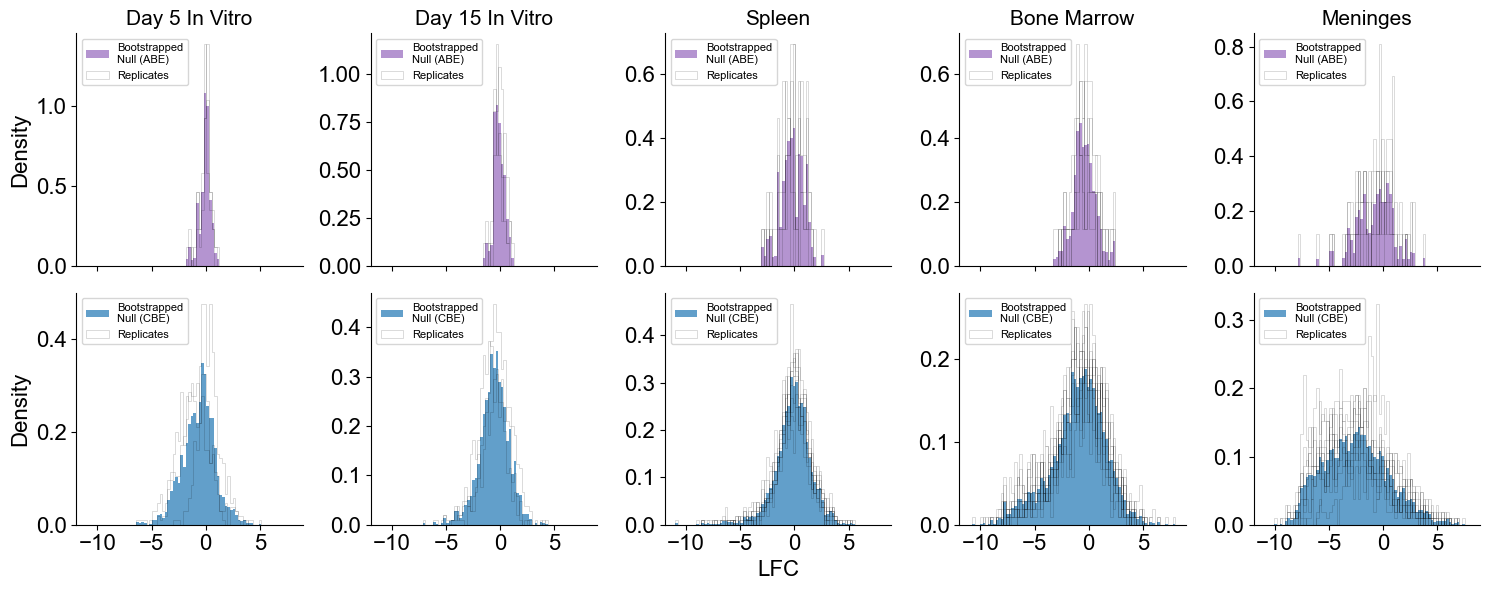

In [93]:
#visualizing the null distributions

fig, ax = plt.subplots(2,5, figsize=(15,6), sharex=True, sharey=False)

conditions = ['d5', 'd15', 'spleen', 'bonemarrow', 'meninges']
name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))

for idx, condition in enumerate(conditions):
    bins = np.linspace(-11,8,80)

    ax[0][idx].hist(ABE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:purple', label='Bootstrapped\nNull (ABE)')
    ax[1][idx].hist(CBE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:blue', label='Bootstrapped\nNull (CBE)')

    ax[0][idx].set_title(name_dict[condition], fontsize=15)

    ax[0][idx].spines[['top', 'right']].set_visible(False)
    ax[1][idx].spines[['top', 'right']].set_visible(False)

    ax[0][idx].tick_params(axis='both', which='major', labelsize=16);
    ax[1][idx].tick_params(axis='both', which='major', labelsize=16);
    
    ax[0][0].set_ylabel('Density', fontsize=16)
    ax[1][0].set_ylabel('Density', fontsize=16)
    ax[1][2].set_xlabel('LFC', fontsize=16)

    ax[0][0].set_xticks([-10,-5,0,  5])

    #also plot the replicates
    samp_of_interest_CBE = CBE_samp_dict[condition]
    samp_of_interest_ABE = ABE_samp_dict[condition]

    for idx2, k in enumerate(samp_of_interest_ABE):
        if idx2==0:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    for idx2, k in enumerate(samp_of_interest_CBE):
        if idx2==0:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    ax[0][idx].legend(fontsize=8, loc='upper left')
    ax[1][idx].legend(fontsize=8, loc='upper left')

fig.tight_layout()

In [ ]:
#first perform computation for ABE samples

conditions = ['d5', 'd15', 'spleen', 'bonemarrow']

df_holder_ABE = []
for condition_of_interest in conditions:

    samp_of_interest = ABE_samp_dict[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, ABE_LFC_table_w_editing, ABE_null_dict)

    df_holder_ABE.append(LFC_df)

combined_LFC_FDR_ABE = pd.concat(df_holder_ABE, axis=1)
combined_LFC_FDR_ABE = combined_LFC_FDR_ABE.loc[:,~combined_LFC_FDR_ABE.columns.duplicated()].copy()

In [95]:
#then do the same for CBE samples
conditions = ['d5', 'd15', 'spleen', 'bonemarrow', 'meninges']

df_holder_CBE = []
for condition_of_interest in conditions:

    samp_of_interest = CBE_samp_dict[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, CBE_LFC_table_w_editing, CBE_null_dict)

    df_holder_CBE.append(LFC_df)

combined_LFC_FDR_CBE = pd.concat(df_holder_CBE, axis=1)
combined_LFC_FDR_CBE = combined_LFC_FDR_CBE.loc[:,~combined_LFC_FDR_CBE.columns.duplicated()].copy()

In [ ]:
combined_LFC_FDR_ABE.to_csv('ABE_LFC_FDR_df_og.csv', index=False)
combined_LFC_FDR_CBE.to_csv('CBE_LFC_FDR_df_og.csv', index=False)

# METHOD 2: EPO vs BC 



## 1. normalize thre read counts of each sample to RPM (reads per million).

In [61]:
fp = 'counts/focused'
ABE_BC_COUNTS = pd.read_csv(fp + '/FC_ABE_BC_COUNTS.txt', sep='\t')
CBE_BC_COUNTS = pd.read_csv(fp + '/FC_CBE_BC_COUNTS_new.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv(fp + '/FC_ABE_EPO_COUNTS.txt', sep='\t')
CBE_EPO_COUNTS = pd.read_csv(fp + '/FC_CBE_EPO_COUNTS_new.txt', sep='\t')

In [62]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_BC_COUNTS.columns[2:])
ABE_BC_RPM = ABE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_BC_RPM[k] = rpm

In [63]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_EPO_COUNTS.columns[2:])
ABE_EPO_RPM = ABE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_EPO_RPM[k] = rpm

In [64]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_BC_COUNTS.columns[2:])
CBE_BC_RPM = CBE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_BC_RPM[k] = rpm

In [65]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_EPO_COUNTS.columns[2:])
CBE_EPO_RPM = CBE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_EPO_RPM[k] = rpm

## 2. Generate LFC tables

In [66]:
def LFC_table_generator_barcoding(RPM_df, RPM_df_bc, samp_dict, samp_dict_bc, t0_comparison):
    """ 
    Function for generating LFC values from barcoding screen
    RPM_df = dataframe containing RPM values of the real screen (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    RPM_df_BC = dataframe containing RPM values of the barcoding screen (generated with pseudocount of +1)
    t0_comparison = list containing base mean values for LFC calculation
    """
    dmso_median = np.median(RPM_df[t0_comparison], axis=1)
    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):
        samp_of_interest = samp_dict[condition_of_interest]
        samp_of_interest_bc = samp_dict_bc[condition_of_interest]
        bc_median = np.median(RPM_df_bc[samp_of_interest_bc], axis=1)
        # print(samp_of_interest)
        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col_epo = RPM_df[k]
            lfc = np.log2(col_epo/bc_median)
            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['Input_median'] = dmso_median
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

In [84]:
ABE_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'],
# ['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5']]
ABE_new_name = ['bm', 'd15', 'd5','input','lib', 'spleen']

CBE_samps_to_merge = [['bm1', 'bm2', 'bm3', 'bm4', 'bm5','bm6','bm7','bm8','bm9','bm10'], 
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'], 
['spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6', 'spleen7', 'spleen8', 'spleen9', 'spleen10']]
CBE_new_name = ['bm', 'd15', 'd5','input','lib', 'spleen']

In [85]:
ABE_SAMP_DICT = dict(zip(ABE_new_name, ABE_samps_to_merge))
CBE_SAMP_DICT = dict(zip(CBE_new_name, CBE_samps_to_merge))
CBE_SAMP_BC_DICT = dict(zip(CBE_new_name, CBE_BC_samps_to_merge))

In [86]:
#generate LFC tables
ABE_EPO_LFC = LFC_table_generator_barcoding(ABE_EPO_RPM, ABE_BC_RPM, ABE_SAMP_DICT, ABE_SAMP_DICT, t0_comparison=['input'])
CBE_EPO_LFC = LFC_table_generator_barcoding(CBE_EPO_RPM, CBE_BC_RPM, CBE_SAMP_DICT, CBE_SAMP_BC_DICT, t0_comparison=['input'])

In [87]:
fp = 'MLE/focused/'
D5_ABE_BC = pd.read_csv(os.path.join(fp,'ABE_BC','d5.csv'))
D5_ABE_EPO = pd.read_csv(os.path.join(fp,'ABE_EPO','d5.csv'))
D5_CBE_BC = pd.read_csv(os.path.join(fp,'CBE_BC_NEW','d5.csv'))
D5_CBE_EPO = pd.read_csv(os.path.join(fp,'CBE_EPO_NEW','d5.csv'))

In [88]:
#and then adding in editing information to the dataframe
ABE_EPO_EDITING = D5_ABE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_EPO_EDITING = ABE_EPO_EDITING[ABE_EPO_EDITING['gRNA_id'].isin(ABE_EPO_COUNTS['sgRNA'])]
ABE_EPO_EDITING.columns = ['gRNA_id','sensor_reads_epo','corr_perc_epo','target_base_edit_perc_epo','byproduct_INDEL_perc_epo','byproduct_sub_perc_epo']

CBE_EPO_EDITING = D5_CBE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_EPO_EDITING = CBE_EPO_EDITING[CBE_EPO_EDITING['gRNA_id'].isin(CBE_EPO_COUNTS['sgRNA'])]
CBE_EPO_EDITING.columns = ['gRNA_id','sensor_reads_epo','corr_perc_epo','target_base_edit_perc_epo','byproduct_INDEL_perc_epo','byproduct_sub_perc_epo']

ABE_BC_EDITING = D5_ABE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_BC_EDITING = ABE_BC_EDITING[ABE_BC_EDITING['gRNA_id'].isin(ABE_BC_COUNTS['sgRNA'])]
ABE_BC_EDITING.columns = ['gRNA_id','sensor_reads_bc','corr_perc_bc','target_base_edit_perc_bc','byproduct_INDEL_perc_bc','byproduct_sub_perc_bc']

CBE_BC_EDITING = D5_CBE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_BC_EDITING = CBE_BC_EDITING[CBE_BC_EDITING['gRNA_id'].isin(CBE_BC_COUNTS['sgRNA'])]
CBE_BC_EDITING.columns = ['gRNA_id','sensor_reads_bc','corr_perc_bc','target_base_edit_perc_bc','byproduct_INDEL_perc_bc','byproduct_sub_perc_bc']

In [89]:
#also add in information about the edits of interest
library = pd.read_csv('MBESv2_focused_with_PAM.csv')[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]
library

,gRNA_id,gene_name_m_corrected,gene_name_h,HGVSp_m,HGVSp_h,classification,classification_m
0,gRNA_2,Abl1,ABL1,Non-coding,NaN,targeting guide,Intron
1,gRNA_4,Abl1,ABL1,E1060K,E1048K,targeting guide,Missense
2,gRNA_19,Abl1,ABL1,P592L,P573L,targeting guide,Missense
3,gRNA_21,Abl1,ABL1,A737T,A719T,targeting guide,Missense
4,gRNA_85,Akt1,AKT1,D323G,D323G,targeting guide,Missense
...,...,...,...,...,...,...,...
1628,gRNA_15007,NaN,NaN,NaN,NaN,non-targeting control,NaN
1629,gRNA_15008,NaN,NaN,NaN,NaN,non-targeting control,NaN
1630,gRNA_15009,NaN,NaN,NaN,NaN,non-targeting control,NaN
1631,gRNA_15010,NaN,NaN,NaN,NaN,non-targeting control,NaN


In [90]:
library['classification'].unique()

array(['targeting guide', 'non-targeting control',
       'essential truncation guide', 'safe-targeting control'],
      dtype=object)

In [91]:
ABE_EDITING = pd.merge(ABE_EPO_EDITING, ABE_BC_EDITING, on='gRNA_id')
ABE_EDITING = pd.merge(ABE_EDITING, library, on='gRNA_id')

In [92]:
CBE_EDITING = pd.merge(CBE_EPO_EDITING, CBE_BC_EDITING, on='gRNA_id')
CBE_EDITING = pd.merge(CBE_EDITING, library, on='gRNA_id')

In [93]:
ABE_LFC_table_w_editing = pd.merge(ABE_EPO_LFC, ABE_EDITING, on='gRNA_id')
CBE_LFC_table_w_editing = pd.merge(CBE_EPO_LFC, CBE_EDITING, on='gRNA_id')

In [94]:
#calculating z-scores for standardization of comparison
samples = ['bm', 'd15', 'd5', 'spleen']
def z_score(df, samples):
    for x in samples:
        col_median = f'LFC_median_{x}'
        avg = np.average(df[col_median])
        std = np.std(df[col_median])
        z_scores = (df[col_median]-avg)/std
        df[f'z_score_{x}'] = z_scores
    return df

ABE_BC_LFC_table_w_editing_z_score = ABE_BC_LFC_table_w_editing.copy()
ABE_EPO_LFC_table_w_editing_z_score = ABE_EPO_LFC_table_w_editing.copy()
CBE_BC_LFC_table_w_editing_z_score = CBE_BC_LFC_table_w_editing.copy()
CBE_EPO_LFC_table_w_editing_z_score = CBE_EPO_LFC_table_w_editing.copy()

ABE_BC_LFC_table_w_editing_z_score = z_score(ABE_BC_LFC_table_w_editing_z_score, samples)
ABE_EPO_LFC_table_w_editing_z_score = z_score(ABE_EPO_LFC_table_w_editing_z_score, samples)
CBE_BC_LFC_table_w_editing_z_score = z_score(CBE_BC_LFC_table_w_editing_z_score, samples)
CBE_EPO_LFC_table_w_editing_z_score = z_score(CBE_EPO_LFC_table_w_editing_z_score, samples)

In [95]:
yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

## 3. Construction & visualization of null distributions

In [96]:
np.random.seed(0)
null=['non-targeting control', 'safe-targeting control']

In [97]:
ABE_controls = ABE_LFC_table_w_editing[ABE_LFC_table_w_editing['classification'].isin(null)].reset_index(drop=True)

In [98]:
ABE_controls

,gRNA_id,Gene,bm1,bm2,bm3,bm4,bm5,LFC_avg_bm,LFC_median_bm,Input_median,...,corr_perc_bc,target_base_edit_perc_bc,byproduct_INDEL_perc_bc,byproduct_sub_perc_bc,gene_name_m_corrected,gene_name_h,HGVSp_m,HGVSp_h,classification,classification_m
0,gRNA_13599,controlsgRNA,-0.358668,0.463620,-0.373438,-0.437052,-2.431657,-0.627439,-0.373438,1512.396445,...,0.0,0.0,0.0,0.0,NT,NaN,Non-coding,NaN,non-targeting control,NaN
1,gRNA_13600,controlsgRNA,-2.307055,-0.692235,-0.056235,-1.466171,-1.358244,-1.175988,-1.358244,2174.664859,...,0.0,0.0,0.0,0.0,NT,NaN,Non-coding,NaN,non-targeting control,NaN
2,gRNA_13601,controlsgRNA,-0.189176,0.094808,-0.688701,0.216714,-0.570926,-0.227456,-0.189176,3982.165989,...,0.0,0.0,0.0,0.0,NT,NaN,Non-coding,NaN,non-targeting control,NaN
3,gRNA_13602,controlsgRNA,1.075173,-0.792009,-0.148884,0.634768,0.044236,0.162657,0.044236,1951.619220,...,0.0,0.0,0.0,0.0,NT,NaN,Non-coding,NaN,non-targeting control,NaN
4,gRNA_13603,controlsgRNA,0.121051,0.841754,-0.334881,-0.801904,1.553989,0.276002,0.121051,2062.238289,...,0.0,0.0,0.0,0.0,NT,NaN,Non-coding,NaN,non-targeting control,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,gRNA_14830,controlsgRNA,-2.055456,-0.667202,-2.005599,-1.318515,-1.231121,-1.455579,-1.318515,4859.045037,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,non-targeting control,NaN
202,gRNA_14831,controlsgRNA,-1.139443,-0.737299,-1.741294,-0.966001,-1.463454,-1.209498,-1.139443,3290.134056,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,non-targeting control,NaN
203,gRNA_14832,controlsgRNA,0.019453,0.481092,0.361712,-0.372300,-0.066234,0.084744,0.019453,6127.187829,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,non-targeting control,NaN
204,gRNA_14833,controlsgRNA,-0.082398,1.379101,-0.437128,-0.564014,0.527391,0.164590,-0.082398,4527.187829,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,non-targeting control,NaN


In [99]:
CBE_controls = CBE_LFC_table_w_editing[CBE_LFC_table_w_editing['classification'].isin(null)].reset_index(drop=True)

In [100]:
#generate null distributions with bootstrapping
conditions = ['d5', 'd15', 'spleen', 'bm']

ABE_bootstrapped_nulls = []
CBE_bootstrapped_nulls = []

for condition in conditions:
    samp_of_interest_CBE = CBE_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_SAMP_DICT[condition]

    #combine replicates and bootstrap sample
    nt_gRNA_values_CBE = CBE_controls[samp_of_interest_CBE].to_numpy().flatten()
    bootstrapped_dist_CBE = np.random.choice(nt_gRNA_values_CBE, size=10000, replace=True)

    nt_gRNA_values_ABE = ABE_controls[samp_of_interest_ABE].to_numpy().flatten()
    bootstrapped_dist_ABE = np.random.choice(nt_gRNA_values_ABE, size=10000, replace=True)

    CBE_bootstrapped_nulls.append(bootstrapped_dist_CBE)
    ABE_bootstrapped_nulls.append(bootstrapped_dist_ABE)

#create dictionaries for both
ABE_null_dict = dict(zip(conditions, ABE_bootstrapped_nulls))
CBE_null_dict = dict(zip(conditions, CBE_bootstrapped_nulls))

In [101]:
len(nt_gRNA_values_CBE)


5660

In [102]:
len(nt_gRNA_values_ABE)

1030

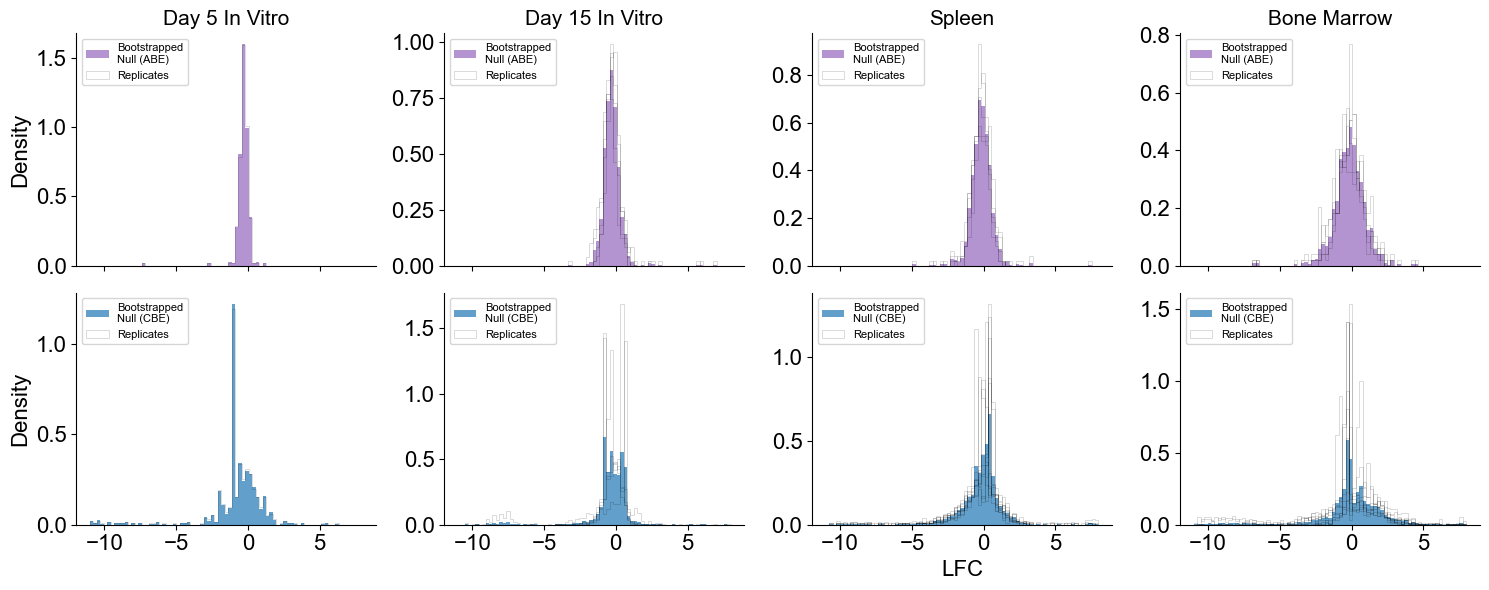

In [104]:
#visualizing the null distributions

fig, ax = plt.subplots(2,4, figsize=(15,6), sharex=True, sharey=False)

conditions = ['d5', 'd15', 'spleen', 'bm', ]
name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', ]))

for idx, condition in enumerate(conditions):
    bins = np.linspace(-11,8,80)

    ax[0][idx].hist(ABE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:purple', label='Bootstrapped\nNull (ABE)')
    ax[1][idx].hist(CBE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:blue', label='Bootstrapped\nNull (CBE)')

    ax[0][idx].set_title(name_dict[condition], fontsize=15)

    ax[0][idx].spines[['top', 'right']].set_visible(False)
    ax[1][idx].spines[['top', 'right']].set_visible(False)

    ax[0][idx].tick_params(axis='both', which='major', labelsize=16);
    ax[1][idx].tick_params(axis='both', which='major', labelsize=16);
    
    ax[0][0].set_ylabel('Density', fontsize=16)
    ax[1][0].set_ylabel('Density', fontsize=16)
    ax[1][2].set_xlabel('LFC', fontsize=16)

    ax[0][0].set_xticks([-10,-5,0,  5])

    #also plot the replicates
    samp_of_interest_CBE = CBE_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_SAMP_DICT[condition]

    for idx2, k in enumerate(samp_of_interest_ABE):
        if idx2==0:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    for idx2, k in enumerate(samp_of_interest_CBE):
        if idx2==0:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    ax[0][idx].legend(fontsize=8, loc='upper left')
    ax[1][idx].legend(fontsize=8, loc='upper left')

fig.tight_layout()
plt.savefig('figures/12_2_null_versus_bc.pdf')

## 4. Empirical p-value & FDR calculation

"Therefore, this simple experiment indicates that there can be significant benefits to using Stouffer’s method in place of Fisher’s method, particularly when long-tailed or off-target effects can be present in the null distribution and are difficult to accurately model."

In [105]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests

# Function to compute empirical p-values
def empirical_p_value(observed, null_distribution):
    S_high = sum(null_distribution >= observed)
    S_low = sum(null_distribution <= observed)
    N = len(null_distribution)

    # Compute two-sided p-value
    p_high = (S_high + 1) / (N + 1)
    p_low = (S_low + 1) / (N + 1)
    return p_high, p_low

def two_sided_FDR(condition_of_interest, samp_of_interest, LFC_df, null_dict):
    ''' 
    condition_of_interest = name of condition (e.g. "spleen")
    samp_of_interest = list of all replicates ["spleen1", "spleen2", "spleen3"]
    LFC_df = dataframe with LFC values
    null_dict = dictionary containing bootstrapped null distributions for each tissue & editor combination
    '''

    # Load the null distribution
    nt_gRNA_values = null_dict[condition_of_interest]

    # Targeting gRNAs (including NT for completeness)
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])
    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    combined_p_values_high_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_high
    ])
    combined_p_values_low_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    adjusted_p_values_high_stouffers = multipletests(combined_p_values_high_stouffers, method='fdr_bh')[1]
    adjusted_p_values_low_stouffers = multipletests(combined_p_values_low_stouffers, method='fdr_bh')[1]

    # Store results in the dataframe
    LFC_df[f'p_high_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_high
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_low
    LFC_df[f'FDR_high_{condition_of_interest}_fishers'] = adjusted_p_values_high
    LFC_df[f'FDR_low_{condition_of_interest}_fishers'] = adjusted_p_values_low

    LFC_df[f'p_high_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_high_stouffers
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_low_stouffers
    LFC_df[f'FDR_high_{condition_of_interest}_stouffers'] = adjusted_p_values_high_stouffers
    LFC_df[f'FDR_low_{condition_of_interest}_stouffers'] = adjusted_p_values_low_stouffers

    #Combine low and high FDRs for ease of manipulation and plotting
    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_fishers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_fishers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_fishers'] = min_FDR

    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_stouffers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_stouffers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_stouffers'] = min_FDR

    return LFC_df

In [106]:
#first perform computation for ABE samples
conditions = ['d5', 'd15', 'spleen', 'bm',]

df_holder_ABE = []
for condition_of_interest in conditions:
    samp_of_interest = ABE_SAMP_DICT[condition_of_interest]
    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, ABE_LFC_table_w_editing, ABE_null_dict)
    df_holder_ABE.append(LFC_df)

combined_LFC_FDR_ABE = pd.concat(df_holder_ABE, axis=1)
combined_LFC_FDR_ABE = combined_LFC_FDR_ABE.loc[:,~combined_LFC_FDR_ABE.columns.duplicated()].copy()

In [107]:
#then do the same for CBE samples
conditions = ['d5', 'd15', 'spleen', 'bm',]

df_holder_CBE = []
for condition_of_interest in conditions:
    samp_of_interest = CBE_SAMP_DICT[condition_of_interest]
    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, CBE_LFC_table_w_editing, CBE_null_dict)
    df_holder_CBE.append(LFC_df)

combined_LFC_FDR_CBE = pd.concat(df_holder_CBE, axis=1)
combined_LFC_FDR_CBE = combined_LFC_FDR_CBE.loc[:,~combined_LFC_FDR_CBE.columns.duplicated()].copy()

In [108]:
#save dataframes
combined_LFC_FDR_ABE.to_csv('LFC-FDR/focused/ABE_LFC_FDR_df_vs_bc.csv', index=False)
combined_LFC_FDR_CBE.to_csv('LFC-FDR/focused/CBE_LFC_FDR_df_vs_bc.csv', index=False)

# METHOD 1: Traditional method; for the BC screen. (Feb 27. 2026)

In [132]:
fp = 'counts/focused'
ABE_BC_COUNTS = pd.read_csv(fp + '/FC_ABE_BC_COUNTS.txt', sep='\t')
CBE_BC_COUNTS = pd.read_csv(fp + '/FC_CBE_BC_COUNTS_new.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv(fp + '/FC_ABE_EPO_COUNTS.txt', sep='\t')
CBE_EPO_COUNTS = pd.read_csv(fp + '/FC_CBE_EPO_COUNTS_new.txt', sep='\t')

In [133]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_BC_COUNTS.columns[2:])
ABE_BC_RPM = ABE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_BC_RPM[k] = rpm

In [134]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(ABE_EPO_COUNTS.columns[2:])
ABE_EPO_RPM = ABE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(ABE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    ABE_EPO_RPM[k] = rpm

In [135]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_BC_COUNTS.columns[2:])
CBE_BC_RPM = CBE_BC_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_BC_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_BC_RPM[k] = rpm

In [136]:
#and normalize to generate RPM values
samples_ABE_BC_RPM = list(CBE_EPO_COUNTS.columns[2:])
CBE_EPO_RPM = CBE_EPO_COUNTS.copy()

#add pseudocount of 1 to each sample
#and normalize + calculate RPM
pseudocount = 1 
for k in samples_ABE_BC_RPM:  
    col = np.asarray(CBE_EPO_COUNTS[k]) + pseudocount
    sum_col = np.sum(col)
    rpm = 1e6*(col/sum_col)
    CBE_EPO_RPM[k] = rpm

## 2. Generate LFC tables

In [137]:
#start with ABE

def LFC_table_generator(RPM_df, samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3']):
    """ 
    Function for generating LFC values
    RPM_df = dataframe containing RPM values (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    t0_comparison = list containing base mean values for LFC calculation
    """

    dmso_median = np.median(RPM_df[t0_comparison], axis=1)

    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):

        samp_of_interest = samp_dict[condition_of_interest]

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM_df[k]
            lfc = np.log2(col/dmso_median)
            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['Input_median'] = dmso_median
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

In [138]:
ABE_EPO_SAMP_DICT = ABE_BC_SAMP_DICT = dict(zip(ABE_EPO_new_name, ABE_EPO_samps_to_merge))
CBE_BC_SAMP_DICT = dict(zip(CBE_BC_new_name, CBE_BC_samps_to_merge))
CBE_EPO_SAMP_DICT = dict(zip(CBE_EPO_new_name, CBE_EPO_samps_to_merge))

In [139]:
#generate LFC tables
ABE_EPO_LFC = LFC_table_generator(ABE_EPO_RPM, ABE_EPO_SAMP_DICT, t0_comparison=['input'])
CBE_EPO_LFC = LFC_table_generator(CBE_EPO_RPM, CBE_EPO_SAMP_DICT, t0_comparison=['input'])
ABE_BC_LFC = LFC_table_generator(ABE_BC_RPM, ABE_BC_SAMP_DICT, t0_comparison=['input'])
CBE_BC_LFC = LFC_table_generator(CBE_BC_RPM, CBE_BC_SAMP_DICT, t0_comparison=['input'])

In [140]:
CBE_BC_SAMP_DICT

{'bm': ['bm1', 'bm2', 'bm3', 'bm4', 'bm5', 'bm6', 'bm7', 'bm8', 'bm9', 'bm10'],
 'd15': ['d15-rep1', 'd15-rep2', 'd15-rep3', 'd15-rep4', 'd15-rep5'],
 'd5': ['d5'],
 'input': ['input'],
 'lib': ['lib'],
 'spleen': ['spleen1',
  'spleen2',
  'spleen3',
  'spleen4',
  'spleen5',
  'spleen6',
  'spleen7',
  'spleen8',
  'spleen9',
  'spleen10']}

In [141]:
fp = 'MLE/focused/'
D5_ABE_BC = pd.read_csv(os.path.join(fp,'ABE_BC','d5.csv'))
D5_ABE_EPO = pd.read_csv(os.path.join(fp,'ABE_EPO','d5.csv'))
D5_CBE_BC = pd.read_csv(os.path.join(fp,'CBE_BC_NEW','d5.csv'))
D5_CBE_EPO = pd.read_csv(os.path.join(fp,'CBE_EPO_NEW','d5.csv'))

In [142]:
#and then adding in editing information to the dataframe
ABE_EPO_EDITING = D5_ABE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_EPO_EDITING = ABE_EPO_EDITING[ABE_EPO_EDITING['gRNA_id'].isin(ABE_EPO_COUNTS['sgRNA'])]

CBE_EPO_EDITING = D5_CBE_EPO[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_EPO_EDITING = CBE_EPO_EDITING[CBE_EPO_EDITING['gRNA_id'].isin(CBE_EPO_COUNTS['sgRNA'])]

ABE_BC_EDITING = D5_ABE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
ABE_BC_EDITING = ABE_BC_EDITING[ABE_BC_EDITING['gRNA_id'].isin(ABE_BC_COUNTS['sgRNA'])]

CBE_BC_EDITING = D5_CBE_BC[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc','target_base_edit_perc', 'byproduct_INDEL_perc','byproduct_sub_perc']].rename(columns = {'Guide_ID':'gRNA_id', 'Reads_aligned_all_amplicons': 'sensor_reads'})
CBE_BC_EDITING = CBE_BC_EDITING[CBE_BC_EDITING['gRNA_id'].isin(CBE_BC_COUNTS['sgRNA'])]

In [143]:
ABE_EPO_EDITING = pd.merge(ABE_EPO_EDITING, library, on='gRNA_id')
ABE_BC_EDITING = pd.merge(ABE_BC_EDITING, library, on='gRNA_id')
CBE_EPO_EDITING = pd.merge(CBE_EPO_EDITING, library, on='gRNA_id')
CBE_BC_EDITING = pd.merge(CBE_BC_EDITING, library, on='gRNA_id')

In [144]:
ABE_BC_LFC_table_w_editing = pd.merge(ABE_BC_LFC, ABE_BC_EDITING, on='gRNA_id')
ABE_EPO_LFC_table_w_editing = pd.merge(ABE_EPO_LFC, ABE_EPO_EDITING, on='gRNA_id')
CBE_BC_LFC_table_w_editing = pd.merge(CBE_BC_LFC, CBE_BC_EDITING, on='gRNA_id')
CBE_EPO_LFC_table_w_editing = pd.merge(CBE_EPO_LFC, CBE_EPO_EDITING, on='gRNA_id')

In [145]:
#calculating z-scores for standardization of comparison
samples = ['bm', 'd15', 'd5', 'spleen']
def z_score(df, samples):
    for x in samples:
        col_median = f'LFC_median_{x}'
        avg = np.average(df[col_median])
        std = np.std(df[col_median])
        z_scores = (df[col_median]-avg)/std
        df[f'z_score_{x}'] = z_scores
    return df

ABE_BC_LFC_table_w_editing_z_score = ABE_BC_LFC_table_w_editing.copy()
ABE_EPO_LFC_table_w_editing_z_score = ABE_EPO_LFC_table_w_editing.copy()
CBE_BC_LFC_table_w_editing_z_score = CBE_BC_LFC_table_w_editing.copy()
CBE_EPO_LFC_table_w_editing_z_score = CBE_EPO_LFC_table_w_editing.copy()

ABE_BC_LFC_table_w_editing_z_score = z_score(ABE_BC_LFC_table_w_editing_z_score, samples)
ABE_EPO_LFC_table_w_editing_z_score = z_score(ABE_EPO_LFC_table_w_editing_z_score, samples)
CBE_BC_LFC_table_w_editing_z_score = z_score(CBE_BC_LFC_table_w_editing_z_score, samples)
CBE_EPO_LFC_table_w_editing_z_score = z_score(CBE_EPO_LFC_table_w_editing_z_score, samples)

In [146]:
yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

## 3. Construction & visualization of null distributions
- w/o bootstrapping?
- with controls in the EPO screen first

In [147]:
#set np random seed for reproducibility
np.random.seed(0)
null=['non-targeting control', 'safe-targeting control']

(array([12., 51., 82., 45., 13.,  2.,  0.,  0.,  0.,  1.]),
 array([6.38650399e+00, 1.33852689e+03, 2.67066727e+03, 4.00280765e+03,
        5.33494803e+03, 6.66708842e+03, 7.99922880e+03, 9.33136918e+03,
        1.06635096e+04, 1.19956499e+04, 1.33277903e+04]),
 <BarContainer object of 10 artists>)

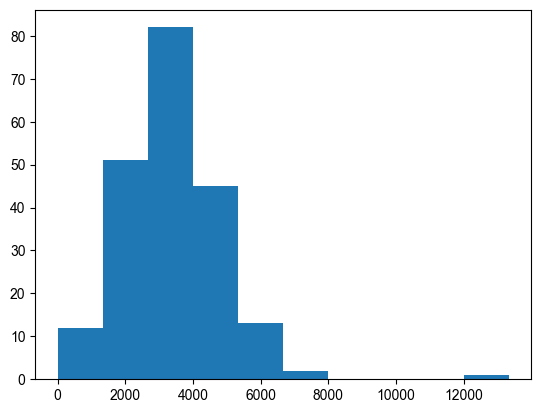

In [148]:
ABE_controls = ABE_BC_LFC_table_w_editing_z_score[ABE_BC_LFC_table_w_editing_z_score['classification'].isin(null)].reset_index(drop=True)
plt.hist(ABE_controls['Input_median'])

(array([234.,  82.,  81.,  66.,  46.,  31.,  16.,   5.,   2.,   3.]),
 array([1.62015945e-01, 2.69853758e+02, 5.39545500e+02, 8.09237242e+02,
        1.07892898e+03, 1.34862073e+03, 1.61831247e+03, 1.88800421e+03,
        2.15769595e+03, 2.42738769e+03, 2.69707944e+03]),
 <BarContainer object of 10 artists>)

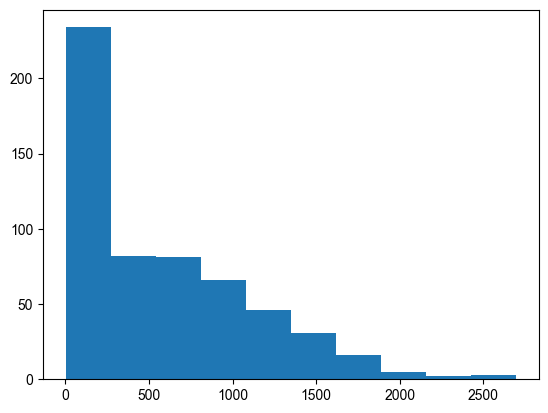

In [149]:
CBE_controls = CBE_BC_LFC_table_w_editing_z_score[CBE_BC_LFC_table_w_editing_z_score['classification'].isin(null)].reset_index(drop=True)
plt.hist(CBE_controls['Input_median'])

In [151]:
#generate null distributions with bootstrapping
conditions = ['d5', 'd15', 'spleen', 'bm', ]

ABE_bootstrapped_nulls = []
CBE_bootstrapped_nulls = []

for condition in conditions:
    samp_of_interest_CBE = CBE_BC_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_BC_SAMP_DICT[condition]

    #combine replicates and bootstrap sample
    nt_gRNA_values_CBE = CBE_controls[samp_of_interest_CBE].to_numpy().flatten()
    bootstrapped_dist_CBE = np.random.choice(nt_gRNA_values_CBE, size=10000, replace=True)

    nt_gRNA_values_ABE = ABE_controls[samp_of_interest_ABE].to_numpy().flatten()
    bootstrapped_dist_ABE = np.random.choice(nt_gRNA_values_ABE, size=10000, replace=True)

    CBE_bootstrapped_nulls.append(bootstrapped_dist_CBE)
    ABE_bootstrapped_nulls.append(bootstrapped_dist_ABE)

#create dictionaries for both
ABE_null_dict = dict(zip(conditions, ABE_bootstrapped_nulls))
CBE_null_dict = dict(zip(conditions, CBE_bootstrapped_nulls))

In [152]:
len(nt_gRNA_values_CBE)

5660

In [153]:
len(nt_gRNA_values_ABE)

1030

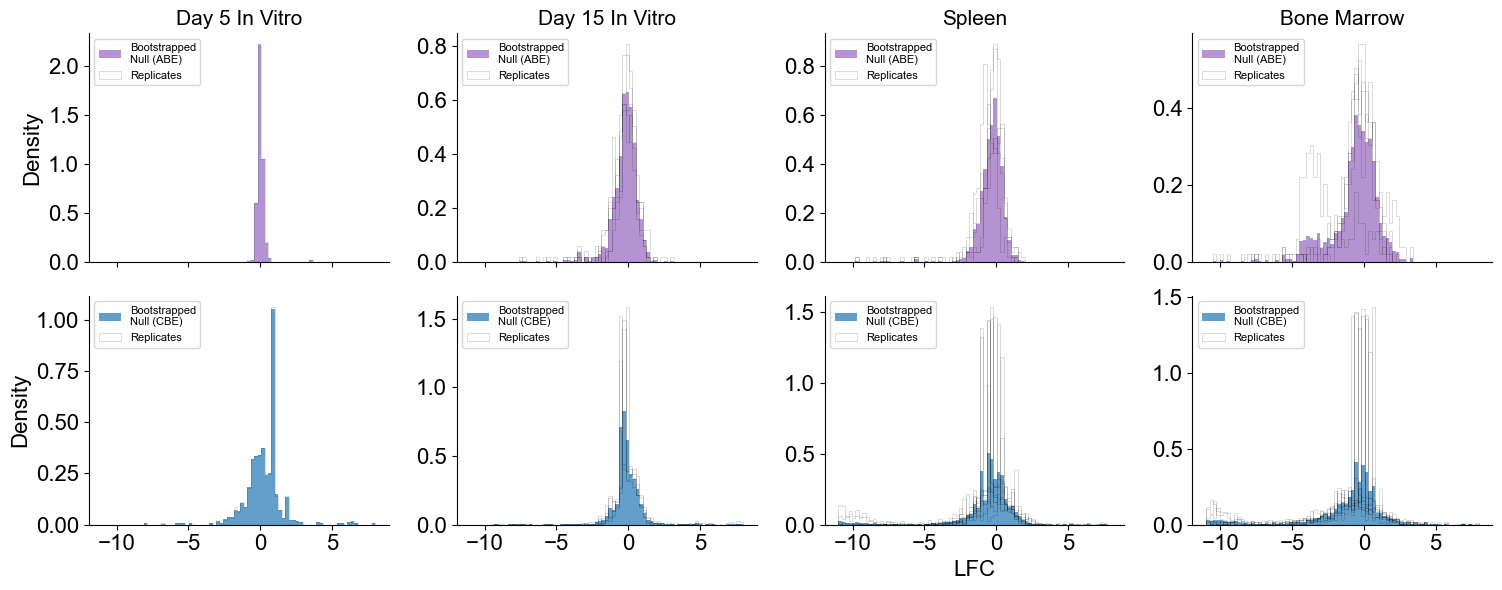

In [157]:
#visualizing the null distributions

fig, ax = plt.subplots(2,4, figsize=(15,6), sharex=True, sharey=False)

conditions = ['d5', 'd15', 'spleen', 'bm', ]
name_dict = dict(zip(conditions, ['Day 5 In Vitro', 'Day 15 In Vitro', 'Spleen', 'Bone Marrow', 'Meninges']))

for idx, condition in enumerate(conditions):
    bins = np.linspace(-11,8,80)

    ax[0][idx].hist(ABE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:purple', label='Bootstrapped\nNull (ABE)')
    ax[1][idx].hist(CBE_null_dict[condition], density=True, bins=bins, alpha=.7, color='tab:blue', label='Bootstrapped\nNull (CBE)')

    ax[0][idx].set_title(name_dict[condition], fontsize=15)

    ax[0][idx].spines[['top', 'right']].set_visible(False)
    ax[1][idx].spines[['top', 'right']].set_visible(False)

    ax[0][idx].tick_params(axis='both', which='major', labelsize=16);
    ax[1][idx].tick_params(axis='both', which='major', labelsize=16);
    
    ax[0][0].set_ylabel('Density', fontsize=16)
    ax[1][0].set_ylabel('Density', fontsize=16)
    ax[1][2].set_xlabel('LFC', fontsize=16)

    ax[0][0].set_xticks([-10,-5,0,  5])

    #also plot the replicates
    samp_of_interest_CBE = CBE_BC_SAMP_DICT[condition]
    samp_of_interest_ABE = ABE_BC_SAMP_DICT[condition]

    for idx2, k in enumerate(samp_of_interest_ABE):
        if idx2==0:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[0][idx].hist(ABE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    for idx2, k in enumerate(samp_of_interest_CBE):
        if idx2==0:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step',label='Replicates')
        else:
            ax[1][idx].hist(CBE_controls[k], density=True, bins=bins, alpha=.2, linewidth=.5, color='black', histtype=u'step')
    
    ax[0][idx].legend(fontsize=8, loc='upper left')
    ax[1][idx].legend(fontsize=8, loc='upper left')

fig.tight_layout()
plt.savefig('figures_new_cbe/12_3_null_epo_bc_screen.pdf')

## 4. Empirical p-value & FDR calculation

In [158]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests

# Function to compute empirical p-values
def empirical_p_value(observed, null_distribution):
    S_high = sum(null_distribution >= observed)
    S_low = sum(null_distribution <= observed)
    N = len(null_distribution)

    # Compute two-sided p-value
    p_high = (S_high + 1) / (N + 1)
    p_low = (S_low + 1) / (N + 1)
    return p_high, p_low

def two_sided_FDR(condition_of_interest, samp_of_interest, LFC_df, null_dict):
    ''' 
    condition_of_interest = name of condition (e.g. "spleen")
    samp_of_interest = list of all replicates ["spleen1", "spleen2", "spleen3"]
    LFC_df = dataframe with LFC values
    null_dict = dictionary containing bootstrapped null distributions for each tissue & editor combination
    '''

    # Load the null distribution
    nt_gRNA_values = null_dict[condition_of_interest]

    # Targeting gRNAs (including NT for completeness)
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])
    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    combined_p_values_high_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_high
    ])
    combined_p_values_low_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    adjusted_p_values_high_stouffers = multipletests(combined_p_values_high_stouffers, method='fdr_bh')[1]
    adjusted_p_values_low_stouffers = multipletests(combined_p_values_low_stouffers, method='fdr_bh')[1]

    # Store results in the dataframe
    LFC_df[f'p_high_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_high
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_low
    LFC_df[f'FDR_high_{condition_of_interest}_fishers'] = adjusted_p_values_high
    LFC_df[f'FDR_low_{condition_of_interest}_fishers'] = adjusted_p_values_low

    LFC_df[f'p_high_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_high_stouffers
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_low_stouffers
    LFC_df[f'FDR_high_{condition_of_interest}_stouffers'] = adjusted_p_values_high_stouffers
    LFC_df[f'FDR_low_{condition_of_interest}_stouffers'] = adjusted_p_values_low_stouffers

    #Combine low and high FDRs for ease of manipulation and plotting
    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_fishers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_fishers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_fishers'] = min_FDR

    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_stouffers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_stouffers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_stouffers'] = min_FDR

    return LFC_df

In [159]:
#first perform computation for ABE samples

conditions = ['d5', 'd15', 'spleen', 'bm', ]

df_holder_ABE = []
for condition_of_interest in conditions:

    samp_of_interest = ABE_BC_SAMP_DICT[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, ABE_BC_LFC_table_w_editing, ABE_null_dict)

    df_holder_ABE.append(LFC_df)

combined_LFC_FDR_ABE_barcoding = pd.concat(df_holder_ABE, axis=1)
combined_LFC_FDR_ABE_barcoding = combined_LFC_FDR_ABE_barcoding.loc[:,~combined_LFC_FDR_ABE_barcoding.columns.duplicated()].copy()

In [160]:

#then do the same for CBE samples
conditions = ['d5', 'd15', 'spleen', 'bm', ]

df_holder_CBE = []
for condition_of_interest in conditions:

    samp_of_interest = CBE_BC_SAMP_DICT[condition_of_interest]

    LFC_df = two_sided_FDR(condition_of_interest, samp_of_interest, CBE_BC_LFC_table_w_editing, CBE_null_dict)

    df_holder_CBE.append(LFC_df)

combined_LFC_FDR_CBE_barcoding = pd.concat(df_holder_CBE, axis=1)
combined_LFC_FDR_CBE_barcoding = combined_LFC_FDR_CBE_barcoding.loc[:,~combined_LFC_FDR_CBE_barcoding.columns.duplicated()].copy()

In [161]:
#save dataframes
combined_LFC_FDR_ABE_barcoding.to_csv('LFC-FDR/focused/ABE_LFC_FDR_df_bc_screen.csv', index=False)
combined_LFC_FDR_CBE_barcoding.to_csv('LFC-FDR/focused/CBE_LFC_FDR_df_bc_screen.csv', index=False)